In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import (
    GroupKFold, GridSearchCV, cross_val_score, KFold
)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor





file_path_EMG = r"D:\ML project\guided\guided_dataset_X.npy"
dataEMG = np.load(file_path_EMG)

file_path_HAND = r"D:\ML project\guided\guided_dataset_y.npy"
dataHAND = np.load(file_path_HAND)


#We start by doing a filtering of our data. "https://www.sciencedirect.com/science/article/pii/S0021929010000631" this paper is a relevant litterature on the subject
#We learn that most of the noise that occurs when recording our sEMG is located in lower frequencies. And that a high-pass filtering at 10hz is highly beneficial with diminishing performance at 20 and 30 hz 
#while still being beneficial as not much revelant signal information is lost.
#As the choice of the frequencie of the high-pass is muscle dependent and as we are limited by our lack of expertise. We will follow the recommendation of the paper and settle at doing a Butterworth filter with a corner frequency of 20 Hz and a slope of 12 dB/oct 
#To do so we will use the butter and filtfilt functions of the scipy library

#In addition, we also learn from this paper "https://iopscience.iop.org/article/10.1088/1742-6596/1237/3/032008/pdf" that most of the sEMG's energy is concentrated in the 0-500hz range 
#Our sampling frenquencie being of 1024hz, twice the bandwith of the signal, by the Nyquist-Shannon theorem we can efficiently control for aliasing up to the 500hz frequencies.
#Even if according to the first paper most of the noise is located in lower frequencies, since relveant information is under the 500hz threshold, ça mange pas de pain to control for higher frequencies.


cutoff_high = 20       # We select (in hz) the cutoff of our high-pass filter
cutoff_low = 500     # We select (in hz) the cutoff of our low-pass filter
order_high = 2         # We select the number of poles. In the Butterworth filter, each pole correspong to 6db, so we select two to get the recommended 12dp/octave
order_low = 4        # Once again we select the number of poles. In the paper the nbr of decibel/octave for the high-pass filter was 24 dB/oct, so we follow this recommendation.

b_high, a_high = butter(order_high, cutoff_high / (1024 / 2), btype='highpass') #The butter function returns the filter coefficients a (denominator),b (numerator). And take as inupts the order and Wn, the desired cutoff frequency being the frequency at which at which the magnitude response of the filter is 1 / √2
b_low, a_low = butter(order_low, cutoff_low / (1024 / 2), btype='lowpass')

first_filtering = filtfilt(b_high, a_high, dataEMG)  #Here we use the filtfilt function, which controls for distortion. That filters forward the backward the forward then blabla, à compléter, pas encore parfaitement compris. https://dsp.stackexchange.com/questions/9467/what-is-the-advantage-of-matlabs-filtfilt 
final_filtering = filtfilt(b_low, a_low, first_filtering)

missingNO = np.isnan(final_filtering).sum()   #Here we simply check that our dataset doesn't have missing values. Or we would have to take that into account for our pipeline
print("Missing Values:", missingNO)   


n_sessions, n_electrodes, n_samples = final_filtering.shape


#Dois encore copier coller les sources.



Missing Values: 0


In [2]:
#We start by "windowing" our data set by creating overlapping windows of size 500ms with a 250ms step betwwen each windows
#this results in the creation of 919 session per electrode, 6433 per session and a total of 25732

ws = 500                # Size of our windows
step = 250              # Distance between the beginning of each windows 2 by 2
n_samples = 230000      # Total time of a session

#To do so we use a nested loop that will go over the data of each electrodes of each session and add it in a two level dictionnary
emg_windows = {}
hand_windows = {}
n_joints     = dataHAND.shape[1]   
n_samples    = dataEMG.shape[2]


for s in range(n_sessions):
    emg_windows[s] = {}
    hand_windows[s] = {}
    for e in range(n_electrodes):
        emg_windows[s][e] = []
        for start in range(0, n_samples - ws + 1, step):
            win = final_filtering[s, e, start : start + ws]
            emg_windows[s][e].append(win)



    for j in range(n_joints):
        hand_windows[s][j] = []
        for start in range(0, n_samples - ws + 1, step):
             win_hand = dataHAND[s, j, start : start + ws]
             hand_windows[s][j].append(win_hand)


    




In [ ]:
from sklearn.model_selection import LeaveOneGroupOut


windows_list = []
hand_last    = []
groups = []


for s in range(5):
    for w in range(918):
        groups.append(s)

        
        emg_stack = np.stack([emg_windows[s][e][w]
                              for e in range(n_electrodes)],
                             axis=0)
        windows_list.append(emg_stack)


        last_samples = [hand_windows[s][j][w][-1]
            for j in range(51)]
        hand_last.append(last_samples)




X = np.stack(windows_list, axis=0) 
Y = np.array(hand_last)
groups = np.array(groups) 

print("X.shape =", X.shape)
print("Y.shape =", Y.shape)
print("groups.shape =", groups.shape)

print(groups)


logo = LeaveOneGroupOut()
logo.get_n_splits(X, Y, groups)
logo.get_n_splits(groups=groups)
print(logo)
for i, (train_index, test_index) in enumerate(logo.split(X, Y, groups)):
    print(f"Fold {i}:")

    print(f"  Train: index={train_index}, group={groups[train_index]}")

    print(f"  Test:  index={test_index}, group={groups[test_index]}")

In [4]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.sigma = 0.05
        self.features_name = ['MAV', 'RMS', 'VAR', 'STD', 'ZC', 'MPR']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        self.sigma = np.std(X)
        windows, channels, window_length = X.shape
        features_number = len(self.features_name)
        transformed = np.zeros((windows, channels * features_number))

        for window in range(windows):
            for channel in range(channels):
                features = self.compute_features(X[window, channel, :])
                transformed[window,
                            channel*features_number:(channel+1)*features_number] = features
        return transformed

    def compute_features(self, x):
        features = [
            np.mean(np.abs(x)),
            np.sqrt(np.mean(x**2)),
            np.var(x, ddof=1),
            np.std(x, ddof=1),
            np.sum(np.diff(np.sign(x)) != 0),
            np.sum(np.abs(x) > self.sigma) / len(x)
        ]
        return features

In [4]:
from tsfresh.feature_extraction import extract_features
from tsfresh.feature_extraction.settings import EfficientFCParameters

class FeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Feature extractor using only tsfresh. It converts 3D EMG windows
    (n_windows, n_channels, window_length) into a pandas DataFrame
    and applies tsfresh to extract a rich set of time-series features.

    Parameters
    ----------
    default_fc_parameters : dict or None
        tsfresh parameter dictionary to control which features are extracted.
        If None, uses EfficientFCParameters().
    n_jobs : int
        Number of processes to use for tsfresh feature extraction.
    """
    def __init__(self, default_fc_parameters=None, n_jobs=1):
        self.settings = default_fc_parameters or EfficientFCParameters()
        self.n_jobs = n_jobs

    def fit(self, X, y=None):
        # No fitting necessary for tsfresh; just store shape info
        if not hasattr(X, 'shape') or X.ndim != 3:
            raise ValueError("X must be a 3D array of shape (n_windows, n_channels, window_length)")
        self.n_windows_, self.n_channels_, self.window_length_ = X.shape
        return self

    def transform(self, X):
        # Build long-format DataFrame for tsfresh
        n_w, n_ch, wlen = X.shape
        # Create identifiers for each observation
        # id: window index, kind: channel index, time: sample index
        id_col = np.repeat(np.arange(n_w), n_ch * wlen)
        kind_col = np.tile(np.repeat(np.arange(n_ch), wlen), n_w)
        time_col = np.tile(np.arange(wlen), n_w * n_ch)
        val_col = X.reshape(-1)
        df = pd.DataFrame({
            'id': id_col,
            'kind': kind_col,
            'time': time_col,
            'value': val_col
        })
        # Extract features with tsfresh
        feature_df = extract_features(
            df,
            column_id='id',
            column_sort='time',
            column_kind='kind',
            column_value='value',
            default_fc_parameters=self.settings,
            n_jobs=self.n_jobs
        )
        # Store feature names
        self.feature_names_ = feature_df.columns.to_numpy()
        # Return numpy array of shape (n_windows, n_features)
        return feature_df.values

    def get_feature_names_out(self, input_features=None):
        if hasattr(self, 'feature_names_'):
            return self.feature_names_
        else:
            raise RuntimeError("Transformer has not been fitted or transformed yet.")


In [64]:
from sklearn.base import BaseEstimator
from scipy.stats    import skew, kurtosis
from scipy.signal   import find_peaks
from numpy.fft      import rfft, rfftfreq

class FeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.sigma = 0.05
        self.features_name = [
            'MAV', 'RMS', 'VAR', 'STD', 'ZC', 'MPR',
            'MED', 'P10', 'P90', 'IQR',
            'SKEW', 'KURT',
            'SLOPE', 'INTERCEPT', 'R2',
            'AC1', 'NPEAKS',
            'SPEC_CENT', 'SPEC_ENT'
        ]

    
    def fit(self, X, y=None):
        _, self.n_channels_, _ = X.shape
        return self

    def transform(self, X):
        self.sigma = np.std(X)
        windows, channels, window_length = X.shape  #window_length nécessaire ?
        features_number = len(self.features_name)
        transformed = np.zeros((windows, channels * features_number))

        self.sigma = np.std(X)
        t = np.arange(window_length)
        
        for window in range(windows):
            for channel in range(channels):
                features = self.compute_features(X[window, channel, :])
                transformed[window, channel*features_number:(channel+1)*features_number] = features
        return transformed


    def get_feature_names_out(self, input_features=None):
        names = []
        for ch in range(self.n_channels_):
            for fn in self.features_name:
                names.append(f"ch{ch}_{fn}")
        return np.array(names)

    def compute_features(self, x):

        t = np.arange(len(x))
        # original features
        mav = np.mean(np.abs(x))
        rms = np.sqrt(np.mean(x**2))
        var = np.var(x, ddof=1)
        std = np.std(x, ddof=1)
        zc = np.sum(np.diff(np.sign(x)) != 0)
        mpr = np.sum(np.abs(x) > self.sigma) / len(x)

        # added basic statistics
        med = np.median(x)
        p10 = np.percentile(x, 10)
        p90 = np.percentile(x, 90)
        iqr = p90 - p10
        sk = skew(x)
        kt = kurtosis(x)

        # trend and fit
        coef = np.polyfit(t, x, 1)
        slope, intercept = coef
        corr = np.corrcoef(t, x)[0, 1]
        r2 = corr**2 if not np.isnan(corr) else 0.0

        # autocorrelation lag-1
        ac1 = np.corrcoef(x[:-1], x[1:])[0, 1] if len(x) > 1 else 0.0

        # peaks
        peaks, _ = find_peaks(x)
        n_peaks = len(peaks)

        # spectral features
        Xf = np.abs(rfft(x))
        freqs = rfftfreq(len(x), 1.0)  # assume unit sampling
        spec_cent = (freqs * Xf).sum() / (Xf.sum() + 1e-12)
        p = Xf / (Xf.sum() + 1e-12)
        spec_ent = -np.sum(p * np.log2(p + 1e-12))

        return [
            mav, rms, var, std, zc, mpr,
            med, p10, p90, iqr,
            sk, kt,
            slope, intercept, r2,
            ac1, n_peaks,
            spec_cent, spec_ent
        ]


            
        


Raw feature‐matrix shape: (4590, 48)
  1 PCs →  74.5% of variance
  2 PCs →  90.8% of variance
  3 PCs →  94.7% of variance
  4 PCs →  97.0% of variance
  5 PCs →  98.5% of variance
  6 PCs →  99.6% of variance
  7 PCs → 100.0% of variance
  8 PCs → 100.0% of variance
  9 PCs → 100.0% of variance
 10 PCs → 100.0% of variance
 11 PCs → 100.0% of variance
 12 PCs → 100.0% of variance
 13 PCs → 100.0% of variance
 14 PCs → 100.0% of variance
 15 PCs → 100.0% of variance
 16 PCs → 100.0% of variance
 17 PCs → 100.0% of variance
 18 PCs → 100.0% of variance
 19 PCs → 100.0% of variance
 20 PCs → 100.0% of variance
 21 PCs → 100.0% of variance
 22 PCs → 100.0% of variance
 23 PCs → 100.0% of variance
 24 PCs → 100.0% of variance
 25 PCs → 100.0% of variance
 26 PCs → 100.0% of variance
 27 PCs → 100.0% of variance
 28 PCs → 100.0% of variance
 29 PCs → 100.0% of variance
 30 PCs → 100.0% of variance
 31 PCs → 100.0% of variance
 32 PCs → 100.0% of variance
 33 PCs → 100.0% of variance
 34 PC

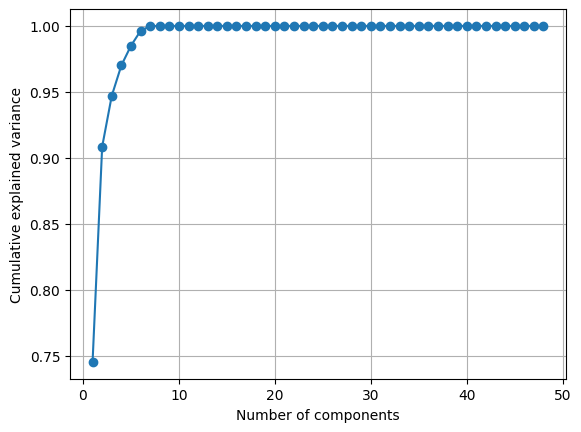

In [5]:
feat = FeatureExtractor()
X_raw = feat.fit_transform(X, Y)    
print("Raw feature‐matrix shape:", X_raw.shape)


from sklearn.decomposition import PCA
pca = PCA().fit(X_raw)


import numpy as np

cumvar = np.cumsum(pca.explained_variance_ratio_)
for i, v in enumerate(cumvar, start=1):
    print(f"{i:3d} PCs → {v*100:5.1f}% of variance")

# 5) (Optionally) visualize the elbow
import matplotlib.pyplot as plt
plt.plot(np.arange(1, len(cumvar)+1), cumvar, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.show()





In [73]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from joblib import Memory

def f_regression_multioutput(X, Y):
    fs, ps = zip(*(f_regression(X, Y[:, i]) for i in range(Y.shape[1])))
    fs = np.mean(fs, axis=0)
    ps = np.mean(ps, axis=0)
    return fs, ps



memory = Memory('cache_dir', verbose=0)

pipe = Pipeline([
    ('feat',   FeatureExtractor()),
    ('pca',    PCA()), 
    ('select', SelectKBest(score_func=f_regression_multioutput)),  
    ('scale',  StandardScaler()),
    ('model',  'passthrough')
], memory=memory)

param_grid = [

  { 'pca__n_components': [7],
    'select__k': [ 5],
    'model': [DecisionTreeRegressor(random_state=42)],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_leaf': [1, 3, 5],
  },

  {  
    'pca__n_components': [7],
    'select__k': [5],
    'model': [RandomForestRegressor(random_state=42, n_jobs=1)],
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [10, 20],
    'model__max_features': ['sqrt', 'log2'],
  },

  #{  
 #   'select__k': [5, 10, 20],
  #  'model': [MultiOutputRegressor(SVR(kernel='rbf'))],
   # 'model__estimator__C': [0.1, 1.0],
    #'model__estimator__epsilon': [0.1, 0.2]
  #}

]
rmse = make_scorer(mean_squared_error, greater_is_better=False, squared=False)

gs = GridSearchCV(
    pipe,
    param_grid,
    cv=logo,                      
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=3
)

gs.fit(X, Y, groups=groups)

results = pd.DataFrame(gs.cv_results_)
results['RMSE'] = -results['mean_test_score']
results = results.sort_values('RMSE')
print(results[['params', 'RMSE']].to_string(index=False))


ValueError: Found array with dim 3. PCA expected <= 2.

In [48]:
import numpy as np

def make_windows_last(X_cont, Y_cont, ws=500, step=250):
    """
    Build windows of EMG and label each one with the joint angles
    at the *last* time‐point of the window.
    
    X_cont: (n_sess, n_ch, n_ts)
    Y_cont: (n_sess, n_j,  n_ts)
    returns:
      Xw: (n_windows, n_ch, ws)
      Yw: (n_windows, n_j)
    """
    n_sess, n_ch, n_ts = X_cont.shape
    _,      n_j,  _    = Y_cont.shape

    Xw, Yw = [], []
    for s in range(n_sess):
        for start in range(0, n_ts - ws + 1, step):
            end = start + ws - 1
            # your EMG window: shape (n_ch, ws)
            win_X = X_cont[s, :, start:end+1]
            # label = joint angles at the *last* sample of the window
            win_y = Y_cont[s, :, end]     # shape (n_j,)
            
            Xw.append(win_X)
            Yw.append(win_y)
    return np.stack(Xw), np.stack(Yw)

# --- usage ---
X_win, Y_win = make_windows_last(freemoves_X, freemoves_Y, ws=500, step=250)
print("Windows:", X_win.shape, "Labels:", Y_win.shape)

Y_pred = best_pipe.predict(X_win)

# 2) RMSE / NMSE
from sklearn.metrics import mean_squared_error

mse  = mean_squared_error(Y_win, Y_pred)
rmse = np.sqrt(mse)
nmse = mse / np.var(Y_win)

print(f"Last‐sample label → RMSE: {rmse:.4f}, NMSE: {nmse:.4f}")


Windows: (5395, 8, 500) Labels: (5395, 51)
Last‐sample label → RMSE: 13.3429, NMSE: 0.3078


In [44]:
import numpy as np
from sklearn.metrics import mean_squared_error
import numpy as np

# Y_win and Y_pred are both shape (n_samples, 51)
mse_per_joint  = ((Y_win - Y_pred) ** 2).mean(axis=0)   # axis 0 = over all samples
rmse_per_joint = np.sqrt(mse_per_joint)

# report the top-5 worst joints
worst = np.argsort(-rmse_per_joint)[:5]
for rank, j in enumerate(worst, 1):
    print(f"{rank}. Joint {j:2d} — RMSE = {rmse_per_joint[j]:.3f}")
# Y_win and Y_pred are shape (5, 308, 51)
mse_per_joint  = ((Y_win - Y_pred) ** 2).mean(axis=(0,1))   # avg over sessions & windows
rmse_per_joint = np.sqrt(mse_per_joint)

# top-5 hardest joints
worst = np.argsort(-rmse_per_joint)[:5]
for rank, j in enumerate(worst, 1):
    print(f"{rank}. Joint {j:2d} — RMSE = {rmse_per_joint[j]:.3f}")

# 1) your fitted pipeline
best_pipe = gs.best_estimator_

# 2) load continuous streams
X_cont = freemoves_X   # shape (5,8,270000)
Y_cont = freemoves_Y   # shape (5,51,270000)

# 3) windowing + two labelling strategies ---------------------------
def make_windows_center(Xc, Yc, ws=500, step=250):
    Xw, Yw = [], []
    for s in range(Xc.shape[0]):
        for start in range(0, Xc.shape[2] - ws + 1, step):
            center = start + ws//2
            Xw.append(Xc[s, :, start:start+ws])
            Yw.append(Yc[s, :, center])
    return np.stack(Xw), np.stack(Yw)

def make_windows_mean(Xc, Yc, ws=500, step=250):
    Xw, Yw = [], []
    for s in range(Xc.shape[0]):
        for start in range(0, Xc.shape[2] - ws + 1, step):
            Xw.append(Xc[s, :, start:start+ws])
            # average over the time‐axis (axis=2) of the window
            Yw.append(Yc[s, :, start:start+ws].mean(axis=2))
    return np.stack(Xw), np.stack(Yw)

# build both sets of windows
X_win_c, Y_win_c = make_windows_center(X_cont, Y_cont)
X_win_m, Y_win_m = make_windows_mean(  X_cont, Y_cont)

# 4) predict & evaluate ---------------------------------------------
def eval(Xw, Yw):
    Ypred = best_pipe.predict(Xw)
    mse    = mean_squared_error(Yw, Ypred)
    rmse   = np.sqrt(mse)
    nmse   = mse / np.var(Yw)
    return rmse, nmse

rmse_c, nmse_c = eval(X_win_c, Y_win_c)
rmse_m, nmse_m = eval(X_win_m, Y_win_m)

print(f"Center‐label → RMSE: {rmse_c:.4f},  NMSE: {nmse_c:.4f}")
print(f"Mean‐label   → RMSE: {rmse_m:.4f},  NMSE: {nmse_m:.4f}")



1. Joint 26 — RMSE = 34.909
2. Joint 17 — RMSE = 32.796
3. Joint 35 — RMSE = 32.177
4. Joint 47 — RMSE = 29.078
5. Joint 20 — RMSE = 25.325


IndexError: invalid index to scalar variable.

In [41]:
selector = best_pipe.named_steps['select']   # your SelectKBest instance

# 1) Raw scores and p-values
scores  = selector.scores_
pvalues = selector.pvalues_

# 2) Which features survived the cut
mask    = selector.get_support()             # boolean array, length = n_features

# 3) Print the top-k selected features by score
selected_indices = np.where(mask)[0]
selected_scores  = scores[mask]

# Sort them descending
order = np.argsort(-selected_scores)
for rank, idx in enumerate(selected_indices[order], 1):
    print(f"{rank:2d}. Feature #{idx:3d} — score = {selected_scores[order][rank-1]:.3f}")


 1. Feature # 29 — score = 1310.849
 2. Feature # 36 — score = 1265.351
 3. Feature # 24 — score = 1110.200
 4. Feature # 39 — score = 1071.683
 5. Feature # 37 — score = 1071.420
 6. Feature # 27 — score = 859.048
 7. Feature # 25 — score = 858.983
 8. Feature # 30 — score = 720.698
 9. Feature # 28 — score = 650.595
10. Feature # 11 — score = 649.774
11. Feature # 35 — score = 637.825
12. Feature # 38 — score = 585.779
13. Feature # 33 — score = 577.601
14. Feature # 31 — score = 577.560
15. Feature #  0 — score = 567.762
16. Feature #  5 — score = 543.847
17. Feature #  1 — score = 505.787
18. Feature #  3 — score = 505.713
19. Feature # 40 — score = 499.711
20. Feature # 41 — score = 443.164


Top 5 hardest-to-predict joints:
1. Joint 26 — RMSE = 34.909
2. Joint 17 — RMSE = 32.796
3. Joint 35 — RMSE = 32.177
4. Joint 47 — RMSE = 29.078
5. Joint 20 — RMSE = 25.325


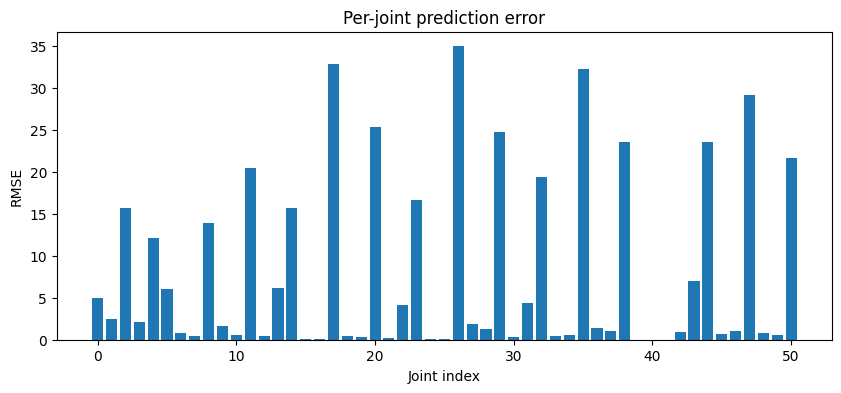

In [43]:
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1) Compute per-joint MSE & RMSE
mse_per_joint  = ((Y_win - Y_pred) ** 2).mean(axis=0)    # shape (51,)
rmse_per_joint = np.sqrt(mse_per_joint)                 # shape (51,)

# 2) Print out the worst joints
worst_idx = np.argsort(-rmse_per_joint)
print("Top 5 hardest-to-predict joints:")
for rank, idx in enumerate(worst_idx[:5], 1):
    print(f"{rank}. Joint {idx:2d} — RMSE = {rmse_per_joint[idx]:.3f}")

# 3) Optional: visualize all joints
plt.figure(figsize=(10,4))
plt.bar(np.arange(51), rmse_per_joint)
plt.xlabel("Joint index")
plt.ylabel("RMSE")
plt.title("Per-joint prediction error")
plt.show()

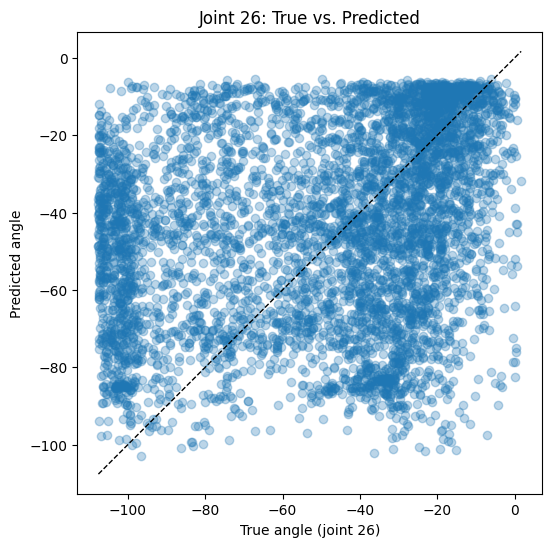

In [49]:
import matplotlib.pyplot as plt

# Suppose Y_win and Y_pred are your (n_windows, 51) arrays
joint = 26
y_true = Y_win[:, joint]
y_hat  = Y_pred[:, joint]

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_hat, alpha=0.3)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'k--', linewidth=1)
plt.xlabel("True angle (joint 26)")
plt.ylabel("Predicted angle")
plt.title("Joint 26: True vs. Predicted")
plt.axis('equal')
plt.show()

In [50]:
import numpy as np

# indices of 3 random windows
idxs = np.random.choice(len(Y_win), size=3, replace=False)

for idx in idxs:
    ts = np.arange(ws)  # 0…499
    # you’ll need to re-extract the window’s raw label signal:
    # here we assume you have stored Y_cont and knows how you mapped windows → indices
    true_trace = Y_cont_flat[idx, joint, :]  # or however you retrieve the full 500-sample trace
    pred_value = Y_pred[idx, joint]
    
    plt.figure()
    plt.plot(ts, true_trace, label="True")
    plt.hlines(pred_value, 0, ws-1, colors='r', linestyles='--', label="Predicted (constant)")
    plt.title(f"Window #{idx}, Joint 26")
    plt.xlabel("Sample in window")
    plt.ylabel("Angle")
    plt.legend()
    plt.show()

NameError: name 'Y_cont_flat' is not defined

In [51]:
import numpy as np

# Suppose feats is your (n_windows, n_features) after FeatureExtractor
corrs = np.corrcoef(feats.T, Y_win[:, joint])[0:feats.shape[1], -1]

# Top 5 features positively correlated
top5 = np.argsort(-np.abs(corrs))[:5]
for i in top5:
    print(f"Feature {i}: corr = {corrs[i]:.3f}")


NameError: name 'feats' is not defined

In [52]:
from sklearn.ensemble import RandomForestRegressor

rf26 = RandomForestRegressor(n_estimators=200, random_state=42)
rf26.fit(feats, Y_win[:, 26])
pred26 = rf26.predict(feats_test)

NameError: name 'feats' is not defined

In [4]:
import torch
import torch.nn as nn
import torch.optim as torchopt
from torch.utils.data import Dataset, DataLoader, Subset



DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class EMGData(Dataset):
    def __init__(self, features, labels):
        self.feats = torch.tensor(features, dtype=torch.float32)
        self.labs = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return self.feats.shape[0]

    def __getitem__(self, id):
        return self.feats[id], self.labs[id]

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.extract = nn.Sequential(
            nn.Conv1d(8,64,7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64,128,5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128,256,3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(10)
        )
        self.final_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*10,512),
            nn.ReLU(),
            nn.Linear(512,128),
            nn.ReLU(),
            nn.Linear(128,51)
        )

    def forward(self, x):
        rep = self.extract(x)
        out = self.final_layer(rep)
        return out

def execute_training(net, dloader_tr, dloader_vl, E=60):
    loss_fn = nn.MSELoss()
    opt = torchopt.Adam(net.parameters(), lr=1e-3)
    sched = torchopt.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

    net.to(DEV)
    lowest_rmse = 99999.0
    save_best = None
    bad_rounds = 0
    max_wait = 10

    for e in range(E):
        net.train()
        for x_, y_ in dloader_tr:
            x_, y_ = x_.to(DEV), y_.to(DEV)
            opt.zero_grad()
            err = loss_fn(net(x_), y_)
            err.backward()
            opt.step()

        
        net.eval()
        preds_buf, labs_buf = [], []
        with torch.no_grad():
            for u, v in dloader_vl:
                u = u.to(DEV)
                y_hat = net(u).cpu()
                preds_buf.append(y_hat)
                labs_buf.append(v)

        preds_val = torch.cat(preds_buf).numpy()
        labs_val = torch.cat(labs_buf).numpy()
        rmse_now = np.sqrt(mean_squared_error(labs_val, preds_val))
        sched.step(rmse_now)

        if rmse_now < lowest_rmse:
            lowest_rmse = rmse_now
            save_best = net.state_dict()
            bad_rounds = 0
        else:
            bad_rounds += 1
            if bad_rounds >= max_wait:
                print("Early stop:", e)
                break

    if save_best:
        net.load_state_dict(save_best)
    return net, lowest_rmse

full_data = EMGData(X, Y)
kf = GroupKFold(n_splits=5)

all_preds, all_trues, all_scores = [], [], []

for i, (tr_indx, vl_indx) in enumerate(kf.split(X, Y, groups=groups)):
    print("Fold:", i)
    tr_dl = DataLoader(Subset(full_data, tr_indx), batch_size=64, shuffle=True)
    vl_dl = DataLoader(Subset(full_data, vl_indx), batch_size=64, shuffle=False)
    mdl = Net()
    mdl, s = execute_training(mdl, tr_dl, vl_dl)
    all_scores.append(s)

    mdl.eval()
    with torch.no_grad():
        x_eval = torch.tensor(X[vl_indx], dtype=torch.float32).to(DEV)
        pred_out = mdl(x_eval).cpu().numpy()
        all_preds.append(pred_out)
        all_trues.append(Y[vl_indx])

print("Mean RMSE:", np.mean(all_scores))



OSError: [WinError 193] %1 n’est pas une application Win32 valide. Error loading "C:\Users\pablo\AppData\Roaming\Python\Python311\site-packages\torch\lib\caffe2_nvrtc.dll" or one of its dependencies.